# 03 — Modeling: predict `is_long_stay` (Dogs & Cats, separately)

Two algorithms, one shared pipeline, compared head to head:
- **Logistic Regression** (regularized) — interpretable baseline
- **XGBoost** — main model

**Iron rules (decided in EDA / feature selection, not changed here):**
1. Dogs and cats are modeled **separately** — their feature signals differ (see §10); never pooled.
2. **Leakage columns never used as features:** `outcome_type, outcome_subtype, outcome_date, length_of_stay_days` — and, **after the target switch to `is_long_stay`, the former target `is_adopted` and `outcome_category`** (both outcome-derived) are leakage sources too. `length_of_stay_days` is the *parent* of the target (`is_long_stay = length_of_stay_days > 30`), so it is doubly disqualified.
3. **Color dropped for both species** (`primary_color, secondary_color, pattern`): floor-level mutual information (<0.002) — confirmed non-useful.
4. `intake_month` droppped: floor-level mutual information (<0.002).

**Selected feature sets** (from the MI / Pearson feature-selection pass):
- **Dog:** `intake_reason, primary_breed, intake_health_condition, sex, age_days, is_sn, is_mix`
- **Cat:** `sex, intake_reason, intake_health_condition, primary_breed, age_days, is_sn, is_mix` — `primary_breed` was a drop candidate (MI 0.001); its keep/drop is settled on the **2023 validation fold** (§7.1), re-checked under the long-stay target, without touching the 2024 test fold.

**Evaluation = rolling-origin backtest (not one split, not random):** for each test year *Y* in 2020–2024, train on all prior years (`intake_year < Y`) and test on *Y*. The long-stay rate drifts across these years (shown by the per-fold output below), so a random split would leak the future; the backtest instead shows how each model holds up year to year — and that drift is exactly why class weights are computed **per fold** (§8), not fixed globally. `intake_year` is used only to build folds, never as a feature.

**Leakage discipline:** every data-driven step (top-N breed thresholds, category sets) is **fit on each fold's training years only**; and all **feature keep/drop decisions (§7) are made on a validation fold** (`train ≤ 2022 → validate 2023`), so the 2024 test fold is never consulted during feature selection.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, brier_score_loss, precision_recall_curve)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('libraries loaded | xgboost + shap OK')

libraries loaded | xgboost + shap OK


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load, filter, build the modeling frame

In [2]:
# ====== EDIT THIS IF YOUR DATA LIVES ELSEWHERE ======
DATA_PATH = '../data/processed/df_full_merged.csv'
# ====================================================
df = pd.read_csv(DATA_PATH)
print('df raw:', df.shape)

TARGET = 'is_long_stay'
if TARGET not in df.columns:                      # guard: CSV may predate is_long_stay
    df[TARGET] = (df['length_of_stay_days'] > 30).astype(int)
    print(f'WARNING: {TARGET} missing — recomputed (length_of_stay_days > 30).')
# Rule 2: leakage columns — listed so they are never selected as features.
# Target switched to is_long_stay, so the former target is_adopted and the outcome-derived
# outcome_category are leakage sources too (both known only after the outcome).
LEAKAGE_COLS = ['outcome_type', 'outcome_subtype', 'outcome_date',
                'length_of_stay_days', 'is_adopted', 'outcome_category']
print('leakage (never used as features):', LEAKAGE_COLS)
print('target:', TARGET)

df raw: (162765, 26)
leakage (never used as features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days', 'is_adopted', 'outcome_category']
target: is_long_stay


## 3. Deterministic feature derivation

These transforms use **no learned parameters** — fixed `age_bucket` bins (missing age → its own `Unknown` bucket), the `is_sn_cat` mapping (missing spay/neuter status → `sn_unknown`, for the LR's one-hot path), a fixed `intake_health_condition` merge that keeps the well-populated levels and folds the rest into `Other`, and filling missing `sex` / `intake_reason` with `'Unknown'` so the encoders never choke — so applying them to the whole frame before the split introduces no leakage. Anything data-driven (top-N breeds) is deferred to the train-only preprocessor in §6. **Color and `intake_month` are intentionally not derived** — neither is in the selected feature sets.

In [3]:
# --- age_bucket for LR (NaN age -> its own 'Unknown' bucket) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = pd.cut(df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS,
                          right=False).astype('object').fillna('Unknown')

# --- is_sn (legal feature: recorded at intake). Unknown sex -> NaN -> explicit category for LR ---
df['is_sn_cat'] = df['is_previously_spayed_neutered'].map({1.0: 'sn_yes', 0.0: 'sn_no'}).fillna('sn_unknown')

# --- intake_health_condition: keep the well-populated levels, merge the rest into 'Other' ---
# (this folds the spec's small categories Medical/Aged/Other, plus other tiny ones, into 'Other')
HEALTH_KEEP = ['Normal', 'Injured', 'Sick', 'Nursing', 'Neonatal']
_before = df['intake_health_condition'].value_counts().to_dict()
df['intake_health_condition'] = df['intake_health_condition'].where(
    df['intake_health_condition'].isin(HEALTH_KEEP), 'Other')
# fill any stray NaN in OHE categorical inputs so encoders never choke
for c in ['sex', 'intake_reason']:
    df[c] = df[c].fillna('Unknown')

print('health_condition merged ->', df['intake_health_condition'].value_counts().to_dict())
print('  (merged out of:', {k: v for k, v in _before.items() if k not in HEALTH_KEEP}, ')')
print('NOTE: color (primary/secondary/pattern) and intake_month are NOT derived — dropped per feature selection.')

health_condition merged -> {'Normal': 139975, 'Injured': 9214, 'Sick': 6004, 'Nursing': 3721, 'Other': 1969, 'Neonatal': 1882}
  (merged out of: {'Medical': 577, 'Aged': 522, 'Other': 337, 'Pregnant': 150, 'Feral': 143, 'Behavior': 80, 'Med Attn': 78, 'Unknown': 29, 'Med Urgent': 21, 'Neurologic': 11, 'Parvo': 11, 'Space': 4, 'Agonal': 4, 'Panleuk': 1, 'Congenital': 1} )
NOTE: color (primary/secondary/pattern) and intake_month are NOT derived — dropped per feature selection.


## 4. Rolling-origin backtest (expanding-window time splits)

We **backtest**: for each test year *Y* in 2020–2024, train on **all** prior years (`intake_year < Y`) and test on *Y* alone. The training window **expands** by one year each step:

| fold | train years | test year | role |
|---|---|---|---|
| 1 | 2013–2019 | 2020 | test |
| 2 | 2013–2020 | 2021 | test |
| 3 | 2013–2021 | 2022 | test |
| 4 | 2013–2022 | 2023 | **validation** (feature decisions, §7) |
| 5 | 2013–2023 | 2024 | **reference** (test + interpretability, §10) |

Every fold is strictly past → future (no leakage, no random split), and every data-driven step is re-fit on that fold's training years only. The long-stay rate drifts across these years (see the per-fold output above), so per-fold scores show **stability over time**, not just one lucky split — and that drift is why class weights are computed **per fold** (§8), never fixed globally.

All **feature keep/drop decisions (§7) are made on the validation fold** — `train ≤ 2022 → validate 2023` — so the 2024 **test** fold is never consulted while choosing features. Only **interpretability (§10)** uses the **reference fold** — the most recent *complete* one.

In [4]:
# ---- rolling-origin backtest folds: test year Y, train = all years < Y (expanding window) ----
TEST_YEARS = [2020, 2021, 2022, 2023, 2024]
REF_TEST_YEAR = 2024   # most recent COMPLETE year -> held-out TEST fold (headline) + §10 interpretability
VAL_TEST_YEAR = 2023   # VALIDATION fold (train <= 2022): ALL §7 feature keep/drop decisions are made here,
                       # so the 2024 test fold is never consulted during feature selection

def fold_frames(test_year):
    tr = df[df.intake_year <  test_year]
    te = df[df.intake_year == test_year]
    return tr, te

print('Rolling-origin folds (expanding window):')
for Y in TEST_YEARS:
    tr, te = fold_frames(Y)
    yr0, yr1 = int(tr.intake_year.min()), int(tr.intake_year.max())
    tag = ('  <- VAL (feature decisions)' if Y == VAL_TEST_YEAR else
           '  <- REF (test + interpret)'  if Y == REF_TEST_YEAR else '')
    print(f'  train {yr0}-{yr1} (n={len(tr):>6,}, long_stay {tr[TARGET].mean():.3f})  ->  '
          f'test {Y} (n={len(te):>5,}, long_stay {te[TARGET].mean():.3f}){tag}')

def species_frames(test_year):
    tr, te = fold_frames(test_year)
    TR = {sp: tr[tr.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
    TE = {sp: te[te.animal_type == sp].copy() for sp in ['Dog', 'Cat']}
    return TR, TE

# VALIDATION fold (train <= 2022 -> validate 2023): §7 feature ablations / keep-drop DECISIONS only.
# REFERENCE fold  (train <= 2023 -> test 2024):     headline test fold + §10 interpretability (final fit).
VAL_TR, VAL_TE = species_frames(VAL_TEST_YEAR)
REF_TR, REF_TE = species_frames(REF_TEST_YEAR)
print(f'\nvalidation fold (feature decisions) = train <= {VAL_TEST_YEAR-1} -> validate {VAL_TEST_YEAR}: '
      + ', '.join(f'{sp} train {len(VAL_TR[sp]):,}/val {len(VAL_TE[sp]):,}' for sp in ['Dog', 'Cat']))
print(f'reference fold  (test + interpret)  = train <= {REF_TEST_YEAR-1} -> test {REF_TEST_YEAR}: '
      + ', '.join(f'{sp} train {len(REF_TR[sp]):,}/test {len(REF_TE[sp]):,}' for sp in ['Dog', 'Cat']))

Rolling-origin folds (expanding window):
  train 2013-2019 (n=106,948, long_stay 0.169)  ->  test 2020 (n=8,853, long_stay 0.239)
  train 2013-2020 (n=115,801, long_stay 0.174)  ->  test 2021 (n=11,313, long_stay 0.217)
  train 2013-2021 (n=127,114, long_stay 0.178)  ->  test 2022 (n=11,165, long_stay 0.246)
  train 2013-2022 (n=138,279, long_stay 0.183)  ->  test 2023 (n=10,648, long_stay 0.307)  <- VAL (feature decisions)
  train 2013-2023 (n=148,927, long_stay 0.192)  ->  test 2024 (n=11,101, long_stay 0.289)  <- REF (test + interpret)



validation fold (feature decisions) = train <= 2022 -> validate 2023: Dog train 82,389/val 5,062, Cat train 55,890/val 5,586
reference fold  (test + interpret)  = train <= 2023 -> test 2024: Dog train 87,451/test 5,073, Cat train 61,476/test 6,028


## 5. Per-species feature sets & breed policy

The feature sets were fixed in the MI/Pearson selection pass (see overview). Here we record them in code, set the breed policy, and print the final per-species feature list. 

In [5]:
# ---- selected feature sets (color + intake_month excluded) ----
FEATURES = {
    'Dog': ['intake_reason', 'primary_breed', 'intake_health_condition', 'sex',
            'age_days', 'is_sn', 'is_mix'],
    'Cat': ['sex', 'intake_reason', 'intake_health_condition', 'primary_breed',
            'age_days', 'is_sn', 'is_mix'],
}
# already checked: FEATURES contains no leakage column (no length_of_stay_days / is_adopted / outcome_category)
DOG_BREED_TOPN, CAT_BREED_TOPN = 20, 4
BREED_TOPN = {'Dog': DOG_BREED_TOPN, 'Cat': CAT_BREED_TOPN}
USE_BREED  = {'Dog': True, 'Cat': True}
for sp in ['Dog', 'Cat']:
    print(f'{sp} features ({len(FEATURES[sp])}): {FEATURES[sp]}')
print('USE_BREED =', USE_BREED, '| BREED_TOPN =', BREED_TOPN)

# cat breed context: most cats are Domestic Shorthair, keep top-4 + fold the rest into 'Other'
ct = VAL_TR['Cat']
g = ct.groupby('primary_breed')[TARGET].agg(rate='mean', n='count')
g = g[g['n'] >= 100].sort_values('n', ascending=False)
print('\nCAT primary_breed long-stay rate (validation-fold train, n>=100):')
print('  (rate column is now the long-stay rate; top-4 coverage is target-independent)')
print(g.round(3).to_string())
cov = ct['primary_breed'].isin(['Domestic Shorthair', 'Domestic Medium Hair',
                                'Domestic Longhair', 'Siamese']).mean()
print(f'top-{CAT_BREED_TOPN} cat breeds cover {cov:.1%} of cats; the rest fold into Other')

Dog features (7): ['intake_reason', 'primary_breed', 'intake_health_condition', 'sex', 'age_days', 'is_sn', 'is_mix']
Cat features (7): ['sex', 'intake_reason', 'intake_health_condition', 'primary_breed', 'age_days', 'is_sn', 'is_mix']
USE_BREED = {'Dog': True, 'Cat': True} | BREED_TOPN = {'Dog': 20, 'Cat': 4}

CAT primary_breed long-stay rate (validation-fold train, n>=100):
  (rate column is now the long-stay rate; top-4 coverage is target-independent)
                       rate      n
primary_breed                     
Domestic Shorthair    0.251  46048
Domestic Medium Hair  0.252   4604
Domestic Longhair     0.224   2147
Siamese               0.211   1784
American Shorthair    0.205    264
Snowshoe              0.279    244
Maine Coon            0.177    158
Manx                  0.270    137
Russian Blue          0.255    110
top-4 cat breeds cover 97.7% of cats; the rest fold into Other


## 6. Shared preprocessing — encoding layer splits by algorithm

The selected features map to columns as:

| feature | LR | XGBoost |
|---|---|---|
| age_days | `age_bucket` one-hot (Unknown bucket) | `age_at_intake_days` raw continuous (NaN native) |
| is_sn | one-hot, `is_sn` x `age` collinearity detected, final decision after ablation test | `is_previously_spayed_neutered` raw 0/1 (NaN native) |
| sex, intake_reason, intake_health_condition | one-hot | one-hot |
| primary_breed (Dog top-20, Cat top-4) | top-N + Other (one-hot, **fit on train**) | top-N + Other |
| is_mix | passthrough 0/1 | passthrough 0/1 |

- `OneHotEncoder(handle_unknown=...)` is fit only inside `.fit(X_train)`
- The top-N breed grouping uses the encoder's infrequent-category mechanism, also train-fitted. - **Dropped:** color and `intake_month` by mutual information test in EDA. 
- `make_preprocessor` exposes `use_breed` and `lr_use_is_sn` flags so §7 can ablate them without touching the main pipeline.

In [6]:
def make_preprocessor(algo, sp, *, use_breed=None, lr_use_is_sn=False):
    if use_breed is None:
        use_breed = USE_BREED[sp]

    ohe_cols = ['intake_reason', 'sex', 'intake_health_condition']
    if algo == 'lr':
        ohe_cols += ['age_bucket']
        if lr_use_is_sn:
            ohe_cols += ['is_sn_cat']

    transformers = [('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols)]

    if use_breed:
        # top-N most frequent breeds + one 'infrequent' (=Other); unseen test breeds -> infrequent
        transformers.append(('breed',
            OneHotEncoder(handle_unknown='infrequent_if_exist',
                          max_categories=BREED_TOPN[sp] + 1, sparse_output=False),
            ['primary_breed']))

    if algo == 'lr':
        transformers.append(('mix', 'passthrough', ['is_mix']))
    else:  # xgb: keep numeric raw incl. is_previously_spayed_neutered (XGB keeps is_sn; handles NaN)
        transformers.append(('num', 'passthrough',
            ['age_at_intake_days', 'is_mix', 'is_previously_spayed_neutered']))

    return ColumnTransformer(transformers, remainder='drop')

# quick sanity: feature count per production config (on the reference fold's training frame)
for sp in ['Dog', 'Cat']:
    for algo in ['lr', 'xgb']:
        ncol = make_preprocessor(algo, sp).fit_transform(REF_TR[sp]).shape[1]
        print(f'{sp} {algo}: {ncol} features')

Dog lr: 46 features


Dog xgb: 39 features


Cat lr: 29 features
Cat xgb: 22 features


In [7]:
def evaluate(model_tag, sp, test_year, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return dict(test_year=test_year, species=sp, model=model_tag, threshold=round(float(thr), 4),
                AUC=roc_auc_score(y_true, proba),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                F1=f1_score(y_true, pred, zero_division=0),
                Brier=brier_score_loss(y_true, proba),
                n_test=len(y_true))

def fit_lr(train_frame, sp, use_breed=None, lr_use_is_sn=False):
    # class_weight='balanced': long-stay (positive) is the minority and its rate drifts year to year,
    # so the weight is recomputed by sklearn from THIS fold's train -> a per-fold balance, never global.
    pipe = Pipeline([('pre', make_preprocessor('lr', sp, use_breed=use_breed, lr_use_is_sn=lr_use_is_sn)),
                     ('clf', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced'))])
    pipe.fit(train_frame, train_frame[TARGET])     # encoders fit on this fold's TRAIN only
    return pipe

def _spw(frame):
    # scale_pos_weight = (#negatives / #positives) on THIS frame; recomputed per frame because the
    # long-stay rate drifts, so inner_tr and full give different weights (kept consistent within each).
    pos = int((frame[TARGET] == 1).sum()); neg = int((frame[TARGET] == 0).sum())
    return neg / pos if pos else 1.0

def tune_and_fit_xgb(train_frame, sp, use_breed=None):
    full = train_frame
    # inner time-aware validation: hold out the LAST training year (never touches the fold's test year)
    val_year  = sorted(full.intake_year.unique())[-1]
    inner_tr  = full[full.intake_year <  val_year]
    inner_val = full[full.intake_year == val_year]
    mk = lambda: make_preprocessor('xgb', sp, use_breed=use_breed)
    pre = mk()
    Ztr, Zval = pre.fit_transform(inner_tr), pre.transform(inner_val)
    spw_inner = _spw(inner_tr)      # weight from the INNER-train years (used for early stopping)
    best = None
    for depth in [3, 5]:
        for lr in [0.03, 0.1]:
            m = XGBClassifier(n_estimators=800, max_depth=depth, learning_rate=lr,
                              subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                              early_stopping_rounds=30, tree_method='hist',
                              scale_pos_weight=spw_inner,
                              n_jobs=4, random_state=RANDOM_STATE)
            m.fit(Ztr, inner_tr[TARGET], eval_set=[(Zval, inner_val[TARGET])], verbose=False)
            if best is None or m.best_score > best['score']:
                best = dict(score=float(m.best_score), depth=depth, lr=lr, n=int(m.best_iteration) + 1)
    # refit on the FULL fold-train; scale_pos_weight recomputed on full (differs from spw_inner because
    # full spans one more year, so early-stopping and final model use weights matched to their OWN data).
    pre2 = mk()
    spw_full = _spw(full)
    final = XGBClassifier(n_estimators=best['n'], max_depth=best['depth'], learning_rate=best['lr'],
                          subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                          tree_method='hist', scale_pos_weight=spw_full,
                          n_jobs=4, random_state=RANDOM_STATE)
    final.fit(pre2.fit_transform(full), full[TARGET])
    return pre2, final, best

# validation-fold AUC helper (used by the §7 ablations)
def val_auc(sp, algo, use_breed=None):
    yval = VAL_TE[sp][TARGET].values
    if algo == 'LR':
        pipe = fit_lr(VAL_TR[sp], sp, use_breed=use_breed)
        proba = pipe.predict_proba(VAL_TE[sp])[:, 1]
    else:
        pre, final, _ = tune_and_fit_xgb(VAL_TR[sp], sp, use_breed=use_breed)
        proba = final.predict_proba(pre.transform(VAL_TE[sp]))[:, 1]
    return roc_auc_score(yval, proba)

# ---- operating-threshold selection (positive class = long-stay) ----
# Chosen on the pooled 2022-2023 out-of-sample folds (§8.1), then applied to the 2024 TEST fold (never the reverse).
def pick_threshold(y_true, proba, target_recall=0.80):
    """Among thresholds with recall >= target_recall, return the one with MAX precision.
    If none reach target_recall, fall back to the threshold whose recall is closest (reached=False)."""
    prec, rec, thr = precision_recall_curve(y_true, proba)
    prec, rec = prec[:-1], rec[:-1]                 # align to thr (drop the no-threshold endpoint)
    ok = rec >= target_recall
    if ok.any():
        cand = np.where(ok)[0]
        best = cand[np.argmax(prec[cand])]
        return float(thr[best]), float(prec[best]), float(rec[best]), True
    i = int(np.argmin(np.abs(rec - target_recall)))
    return float(thr[i]), float(prec[i]), float(rec[i]), False

def recall_sensitivity(y_true, proba, recalls=(0.70, 0.75, 0.80, 0.85)):
    """precision + threshold achievable at each target recall on the given (pooled out-of-sample) predictions."""
    out = []
    for rt in recalls:
        t, pcs, rc, ok = pick_threshold(y_true, proba, target_recall=rt)
        out.append(dict(target_recall=rt, threshold=round(t, 4), precision=round(pcs, 3),
                        achieved_recall=round(rc, 3), reached=ok))
    return pd.DataFrame(out)

BT = []           # one row per (test_year, species, model)
BT_PRED = {}      # (test_year, species, model) -> (y_true, proba), for pooled calibration/confusion
CHOSEN_THR = {}   # (species, model) -> operating threshold chosen on the pooled 2022-2023 out-of-sample folds
LR_MODELS = {}    # species -> reference-fold fitted Pipeline           (for §10)
XGB_MODELS = {}   # species -> reference-fold (preprocessor, booster)   (for §10)

## 7. Feature ablations (on the validation fold)

Every keep/drop decision below is made on the **validation fold** — `train ≤ 2022 → validate 2023` — 2024 test fold is never consulted during feature selection.

1. **`primary_breed` for cats — keep or drop?** MI was 0.001 (argues drop), so we settle it on held-out **validation** AUC rather than the MI score alone.
2. **`is_sn` × `age` collinearity (§7.2)** — `is_sn` is correlated with `age`; we quantify it (VIF) and measure what dropping it costs the LR.

_These feature sets were originally selected under the `is_adopted` target; each keep/drop is **re-validated on the 2023 validation fold under the long-stay target** (the 2024 test fold never participates). The calls below follow the freshly recomputed AUC deltas, not any prior adoption-era conclusion._

In [8]:
# ===== 1. cat primary_breed check on the VALIDATION fold: val AUC with vs without breed =====
cat_breed_abl = []
for algo in ['LR', 'XGB']:
    a = val_auc('Cat', algo, use_breed=True)
    b = val_auc('Cat', algo, use_breed=False)
    cat_breed_abl.append(dict(model=algo, AUC_with_breed=a, AUC_without_breed=b, delta=a - b))
cba = pd.DataFrame(cat_breed_abl)
print(f'Cat primary_breed ablation — validation fold (validate {VAL_TEST_YEAR}) AUC, with vs without breed:')
print(cba.round(4).to_string(index=False))
xgb_delta = cba.loc[cba.model == 'XGB', 'delta'].iloc[0]
print(f'Validation-fold delta (XGB) = {xgb_delta:+.4f} — re-checked under the long-stay target (2024 test fold untouched).')
print('Read off the delta above: ~0 => breed is neutral on this validation fold; clearly +/- => it helps/hurts here.')
print('No fixed keep/drop is asserted — the call follows this validation delta, not a prior adoption-era result.')

Cat primary_breed ablation — validation fold (validate 2023) AUC, with vs without breed:
model  AUC_with_breed  AUC_without_breed   delta
   LR          0.6949             0.6948  0.0001
  XGB          0.7362             0.7365 -0.0003
Validation-fold delta (XGB) = -0.0003 — re-checked under the long-stay target (2024 test fold untouched).
Read off the delta above: ~0 => breed is neutral on this validation fold; clearly +/- => it helps/hurts here.
No fixed keep/drop is asserted — the call follows this validation delta, not a prior adoption-era result.


In [9]:
# ===== 2. is_sn x age collinearity in the LR (mild -> use ablation test for final feature selection decision) =====
print(f'Validation fold (train <= {VAL_TEST_YEAR-1}, validate {VAL_TEST_YEAR}).  VIF = 1 / (1 - corr^2).')
rows = []
for sp in ['Dog', 'Cat']:
    d = VAL_TR[sp]
    m = d['is_previously_spayed_neutered'].notna() & d['age_at_intake_days'].notna()
    r = np.corrcoef(d.loc[m, 'is_previously_spayed_neutered'], d.loc[m, 'age_at_intake_days'])[0, 1]
    yval = VAL_TE[sp][TARGET].values
    auc_with = roc_auc_score(yval, fit_lr(VAL_TR[sp], sp, lr_use_is_sn=True ).predict_proba(VAL_TE[sp])[:, 1])
    auc_drop = roc_auc_score(yval, fit_lr(VAL_TR[sp], sp, lr_use_is_sn=False).predict_proba(VAL_TE[sp])[:, 1])
    rows.append(dict(species=sp, corr_is_sn_age=round(r, 3), VIF=round(1 / (1 - r**2), 2),
                     LR_AUC_with_is_sn=round(auc_with, 4), LR_AUC_drop_is_sn=round(auc_drop, 4),
                     delta=round(auc_drop - auc_with, 4)))
print(pd.DataFrame(rows).to_string(index=False))
print('\nVIF is computed above; well under the usual 5-10 flag means the is_sn/age collinearity is mild.')
print('Compare LR_AUC_with_is_sn vs LR_AUC_drop_is_sn (delta) on this 2023 validation fold, long-stay target:')
print('a near-zero delta => is_sn is redundant for the LR and can be dropped at ~no cost; XGB keeps it')
print('(no coefficient-variance issue, usable in interactions). The call follows this re-checked delta.')


Validation fold (train <= 2022, validate 2023).  VIF = 1 / (1 - corr^2).


species  corr_is_sn_age  VIF  LR_AUC_with_is_sn  LR_AUC_drop_is_sn   delta
    Dog           0.411 1.20             0.6415             0.6385 -0.0030
    Cat           0.590 1.53             0.6983             0.6949 -0.0034

VIF is computed above; well under the usual 5-10 flag means the is_sn/age collinearity is mild.
Compare LR_AUC_with_is_sn vs LR_AUC_drop_is_sn (delta) on this 2023 validation fold, long-stay target:
a near-zero delta => is_sn is redundant for the LR and can be dropped at ~no cost; XGB keeps it
(no coefficient-variance issue, usable in interactions). The call follows this re-checked delta.


## 8. Train & backtest on every fold (LR + XGB, per species)

- Validation: Time-aware CV (train on past years, test on the next single year).
- LR: Fit directly with fixed L2 regularization (C=1.0).
- XGBoost: Nested CV for tuning. Uses the last training year as an inner validation set to optimize parameters without leaking test data, then refits on the full training window.
- Preprocessing: Encoders and Top-N breeds are re-fit per fold on training data only. No feature scaling is applied: the LR sees only one-hot / 0–1 columns, and XGBoost is a tree model (scale-invariant) fed the raw continuous age_at_intake_days.
- Artifacts: 2024 test-fold models are saved for §10.

In [10]:
# ---------------- Logistic Regression — backtest across folds ----------------
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        pipe  = fit_lr(tr, sp)
        proba = pipe.predict_proba(te)[:, 1]
        yte   = te[TARGET].values
        BT.append(evaluate('LR', sp, Y, yte, proba))
        BT_PRED[(Y, sp, 'LR')] = (yte, proba)
        if Y == REF_TEST_YEAR:
            LR_MODELS[sp] = pipe
print('LR backtest done. Per-fold test AUC (cols = test year):')
_lr = pd.DataFrame([r for r in BT if r['model'] == 'LR'])
print(_lr.pivot_table(index='species', columns='test_year', values='AUC').round(3).to_string())

LR backtest done. Per-fold test AUC (cols = test year):
test_year   2020   2021   2022   2023   2024
species                                     
Cat        0.683  0.683  0.683  0.695  0.711
Dog        0.766  0.760  0.737  0.638  0.649


In [11]:
# ---------------- XGBoost — backtest across folds (time-aware inner tuning re-done per fold) ----------------
for Y in TEST_YEARS:
    tr_all, te_all = fold_frames(Y)
    for sp in ['Dog', 'Cat']:
        tr, te = tr_all[tr_all.animal_type == sp], te_all[te_all.animal_type == sp]
        pre, final, best = tune_and_fit_xgb(tr, sp)
        proba = final.predict_proba(pre.transform(te))[:, 1]
        yte   = te[TARGET].values
        BT.append(evaluate('XGB', sp, Y, yte, proba))
        BT_PRED[(Y, sp, 'XGB')] = (yte, proba)
        if Y == REF_TEST_YEAR:
            XGB_MODELS[sp] = (pre, final)
    print(f'  ...XGB fold test {Y} done')
print('XGB backtest done. Per-fold test AUC (cols = test year):')
_xgb = pd.DataFrame([r for r in BT if r['model'] == 'XGB'])
print(_xgb.pivot_table(index='species', columns='test_year', values='AUC').round(3).to_string())

  ...XGB fold test 2020 done


  ...XGB fold test 2021 done


  ...XGB fold test 2022 done


  ...XGB fold test 2023 done


  ...XGB fold test 2024 done
XGB backtest done. Per-fold test AUC (cols = test year):
test_year   2020   2021   2022   2023   2024
species                                     
Cat        0.728  0.740  0.730  0.736  0.751
Dog        0.782  0.781  0.762  0.692  0.708


### 8.1 Operating threshold — chosen on pooled 2022–2023 out-of-sample predictions (recall ≥ 0.80, max precision)

Positive class = **long-stay**, and operationally we would rather over-flag than miss an animal that will linger, so we target **high recall**. We pick, per (species, model), the threshold with the best precision among thresholds reaching recall ≥ 0.80, store it, and later apply it to the **2024 test fold** (the test fold never participates in choosing the threshold).

**Threshold is chosen on the *pooled* 2022 + 2023 out-of-sample predictions, not on 2023 alone.** 2023 is the historical peak in the long-stay rate (dogs 0.315 — see the appendix diagnostic), so calibrating on 2023 by itself would bias the operating point toward an unusually high long-stay rate and over-flag in lower-rate years; pooling 2022 dilutes that spike. Both folds' probabilities are already **expanding-window out-of-sample** (2022 ← train ≤ 2021, 2023 ← train ≤ 2022), so concatenating them introduces no leakage, and **2024 stays a clean held-out test fold**. The sensitivity table (on the same pooled 2022–2023 predictions) shows the precision you trade for higher recall — the operational trade-off is left to the user.

In [12]:
# Threshold chosen on the POOLED 2022 + 2023 out-of-sample predictions; applied to the 2024 test fold in §9.
# 2023 is the historical long-stay peak (dogs 0.315), so picking on 2023 alone biases the operating point
# high; pooling 2022 dilutes that spike. Both folds' probas are already expanding-window out-of-sample
# (2022 <- train <= 2021, 2023 <- train <= 2022), so concatenating them is leakage-free. 2024 is NEVER used here.
TARGET_RECALL = 0.80
THR_POOL_YEARS = [2022, 2023]   # out-of-sample folds pooled to pick the operating threshold (2024 excluded)
assert REF_TEST_YEAR not in THR_POOL_YEARS, 'test fold (2024) must never enter threshold selection'

def pooled_thr_preds(sp, tag):
    """Concatenate (y_true, proba) across THR_POOL_YEARS — each fold's proba is already out-of-sample."""
    yt = np.concatenate([BT_PRED[(Y, sp, tag)][0] for Y in THR_POOL_YEARS])
    pp = np.concatenate([BT_PRED[(Y, sp, tag)][1] for Y in THR_POOL_YEARS])
    return yt, pp

print(f'Threshold + sensitivity use ONLY pooled out-of-sample folds {THR_POOL_YEARS} '
      f'(test fold {REF_TEST_YEAR} EXCLUDED).\n')
print(f'Operating threshold per (species, model), chosen on pooled {THR_POOL_YEARS} out-of-sample predictions '
      f'(recall >= {TARGET_RECALL}, then max precision):\n')
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        yv, pv = pooled_thr_preds(sp, tag)
        t, pcs, rc, ok = pick_threshold(yv, pv, target_recall=TARGET_RECALL)
        CHOSEN_THR[(sp, tag)] = t
        warn = '' if ok else '   (WARNING: recall>=target unreachable; using closest recall)'
        print(f'  {sp:3} {tag:3}: threshold={t:.3f}  ->  pooled recall={rc:.3f}, pooled precision={pcs:.3f}{warn}')

# Sensitivity: how much precision you give up to catch more long-stay animals — SAME pooled 2022-2023 basis
# as the chosen threshold above, so the trade-off shown matches the actual selection rule.
print(f'\nThreshold sensitivity on the pooled {THR_POOL_YEARS} folds (target recall vs the precision you get):')
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        yv, pv = pooled_thr_preds(sp, tag)
        print(f'\n=== {sp} {tag} (pooled {THR_POOL_YEARS}) ===')
        print(recall_sensitivity(yv, pv).to_string(index=False))
print('\nNo single best threshold is asserted — catching more long-stay animals costs precision; the call is operational.')

Threshold + sensitivity use ONLY pooled out-of-sample folds [2022, 2023] (test fold 2024 EXCLUDED).

Operating threshold per (species, model), chosen on pooled [2022, 2023] out-of-sample predictions (recall >= 0.8, then max precision):

  Dog LR : threshold=0.385  ->  pooled recall=0.801, pooled precision=0.363
  Dog XGB: threshold=0.387  ->  pooled recall=0.802, pooled precision=0.370
  Cat LR : threshold=0.393  ->  pooled recall=0.800, pooled precision=0.358
  Cat XGB: threshold=0.401  ->  pooled recall=0.801, pooled precision=0.399

Threshold sensitivity on the pooled [2022, 2023] folds (target recall vs the precision you get):

=== Dog LR (pooled [2022, 2023]) ===
 target_recall  threshold  precision  achieved_recall  reached
          0.70     0.4463      0.383            0.709     True
          0.75     0.4194      0.377            0.751     True
          0.80     0.3851      0.363            0.801     True
          0.85     0.3301      0.341            0.850     True

=== Dog

## 9. Backtest results — per-fold AUC stability + headline at the operating threshold

Positive class = **long-stay**. The headline is **recall / precision at the operating threshold** chosen on the pooled 2022–2023 out-of-sample predictions (§8.1) and applied to the held-out **2024 test fold** — **recall matters most** here (don't miss animals that will linger). AUC (threshold-free) is reported alongside as a ranking-quality check, with its per-fold trajectory showing stability over time.

HEADLINE — 2024 test fold at the operating threshold (chosen on pooled [2022, 2023]); positive class = long-stay, recall prioritized:
species model  threshold  recall  precision    F1   AUC  n_test
    Dog    LR      0.385   0.791      0.361 0.496 0.649    5073
    Dog   XGB      0.387   0.719      0.394 0.509 0.708    5073
    Cat    LR      0.393   0.823      0.364 0.505 0.711    6028
    Cat   XGB      0.401   0.830      0.391 0.531 0.751    6028

AUC stability over folds (mean +/- std across test years 2020-2024; threshold-free):
               AUC_mean  AUC_std  Brier_mean  folds
species model                                      
Cat     LR        0.691    0.012       0.234      5
        XGB       0.737    0.009       0.215      5
Dog     LR        0.710    0.062       0.219      5
        XGB       0.745    0.042       0.204      5

Per-fold test AUC (rows = species | model, cols = test year):
test_year       2020   2021   2022   2023   2024
species model                       

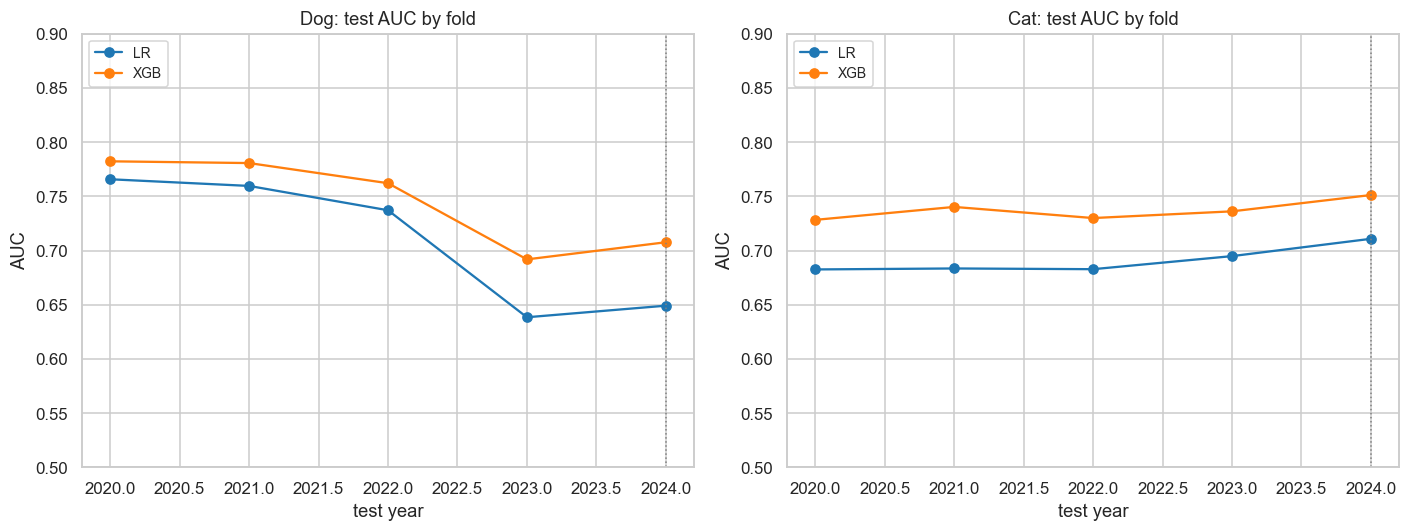

NOTE: dotted line = reference/test fold (2024). Headline recall/precision is at the chosen threshold; AUC is threshold-free.


In [13]:
bt = pd.DataFrame(BT)

# ---- HEADLINE: 2024 test fold scored at the operating threshold chosen on pooled 2022-2023 (§8.1) ----
head = []
for sp in ['Dog', 'Cat']:
    for tag in ['LR', 'XGB']:
        yte, pte = BT_PRED[(REF_TEST_YEAR, sp, tag)]
        head.append(evaluate(tag, sp, REF_TEST_YEAR, yte, pte, thr=CHOSEN_THR[(sp, tag)]))
head = pd.DataFrame(head)[['species', 'model', 'threshold', 'recall', 'precision', 'F1', 'AUC', 'n_test']]
print(f'HEADLINE — {REF_TEST_YEAR} test fold at the operating threshold (chosen on pooled {THR_POOL_YEARS}); '
      'positive class = long-stay, recall prioritized:')
print(head.round(3).to_string(index=False))

# ---- AUC stability across folds (threshold-free, supporting evidence) ----
agg = (bt.groupby(['species', 'model'])
         .agg(AUC_mean=('AUC', 'mean'), AUC_std=('AUC', 'std'),
              Brier_mean=('Brier', 'mean'), folds=('AUC', 'size'))
         .round(3))
print('\nAUC stability over folds (mean +/- std across test years 2020-2024; threshold-free):')
print(agg.to_string())

print('\nPer-fold test AUC (rows = species | model, cols = test year):')
print(bt.pivot_table(index=['species', 'model'], columns='test_year', values='AUC').round(3).to_string())

# AUC trajectory across folds, one panel per species
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for model, c in [('LR', 'tab:blue'), ('XGB', 'tab:orange')]:
        sub = bt[(bt.species == sp) & (bt.model == model)].sort_values('test_year')
        ax.plot(sub.test_year, sub.AUC, marker='o', label=model, color=c)
    ax.axvline(REF_TEST_YEAR, color='gray', ls=':', lw=1)
    ax.set_title(f'{sp}: test AUC by fold'); ax.set_xlabel('test year'); ax.set_ylabel('AUC')
    ax.set_ylim(0.5, 0.9); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()
print('NOTE: dotted line = reference/test fold (2024). Headline recall/precision is at the chosen threshold; AUC is threshold-free.')

### 9.1 Confusion matrices (at each model's operating threshold, predictions pooled across all backtest folds)

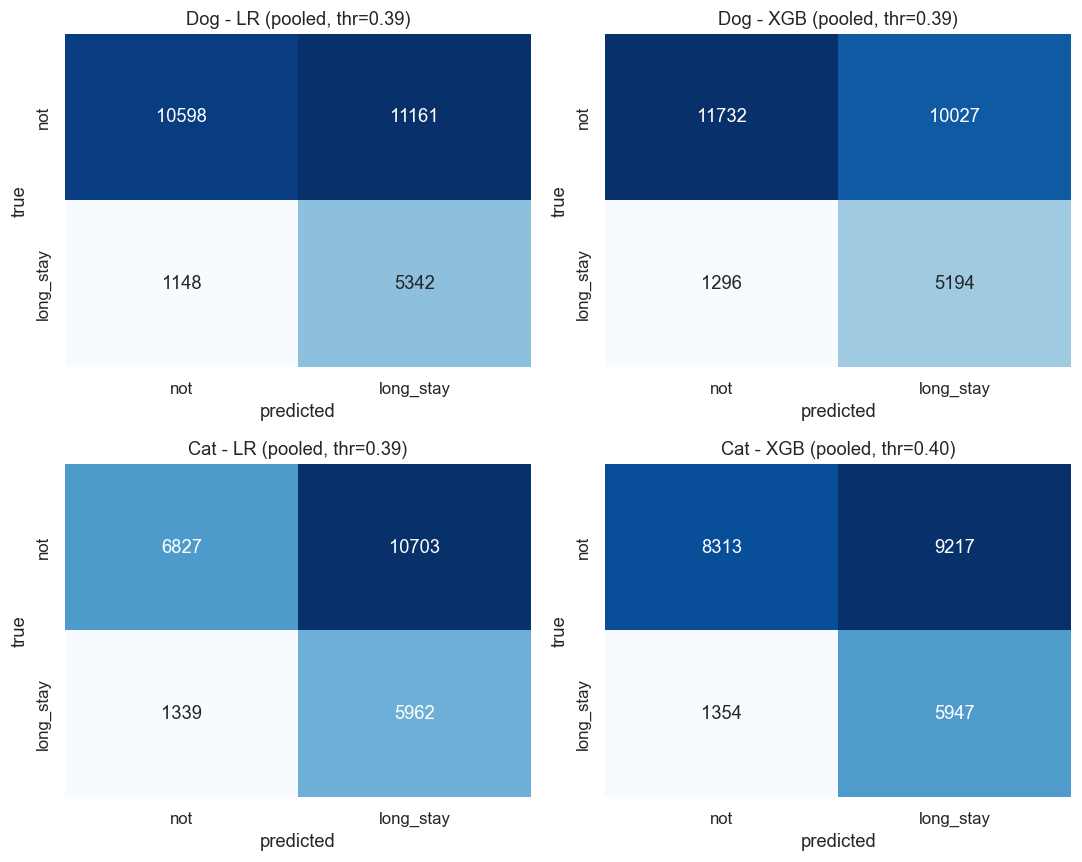

In [14]:
# pool every fold's out-of-sample predictions (each year predicted by a model trained only on its past)
def pooled(sp, tag):
    ys = np.concatenate([BT_PRED[(Y, sp, tag)][0] for Y in TEST_YEARS])
    ps = np.concatenate([BT_PRED[(Y, sp, tag)][1] for Y in TEST_YEARS])
    return ys, ps

order = [('Dog', 'LR'), ('Dog', 'XGB'), ('Cat', 'LR'), ('Cat', 'XGB')]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (sp, tag) in zip(axes.ravel(), order):
    ys, ps = pooled(sp, tag)
    cm = confusion_matrix(ys, (ps >= CHOSEN_THR[(sp, tag)]).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['not', 'long_stay'], yticklabels=['not', 'long_stay'])
    ax.set_title(f'{sp} - {tag} (pooled, thr={CHOSEN_THR[(sp, tag)]:.2f})'); ax.set_xlabel('predicted'); ax.set_ylabel('true')
fig.tight_layout(); plt.show()

### 9.2 Calibration (reliability), pooled across folds — essential given the time drift; AUC alone is not enough

**Calibration is intentionally distorted here.** Because we apply per-fold class weighting (LR `class_weight='balanced'`, XGB `scale_pos_weight`), the models over-weight the minority long-stay class, so predicted probabilities run **systematically high** and the Brier score / reliability curve look worse than an unweighted fit. This is a **known, accepted cost — not a bug**: the operating goal needs only correct *ranking* (AUC) and *recall at the chosen threshold* (§8.1), which weighting improves. If trustworthy probabilities are ever required, fit an isotonic or Platt calibrator on a held-out fold; the curves below are shown as-is for transparency.

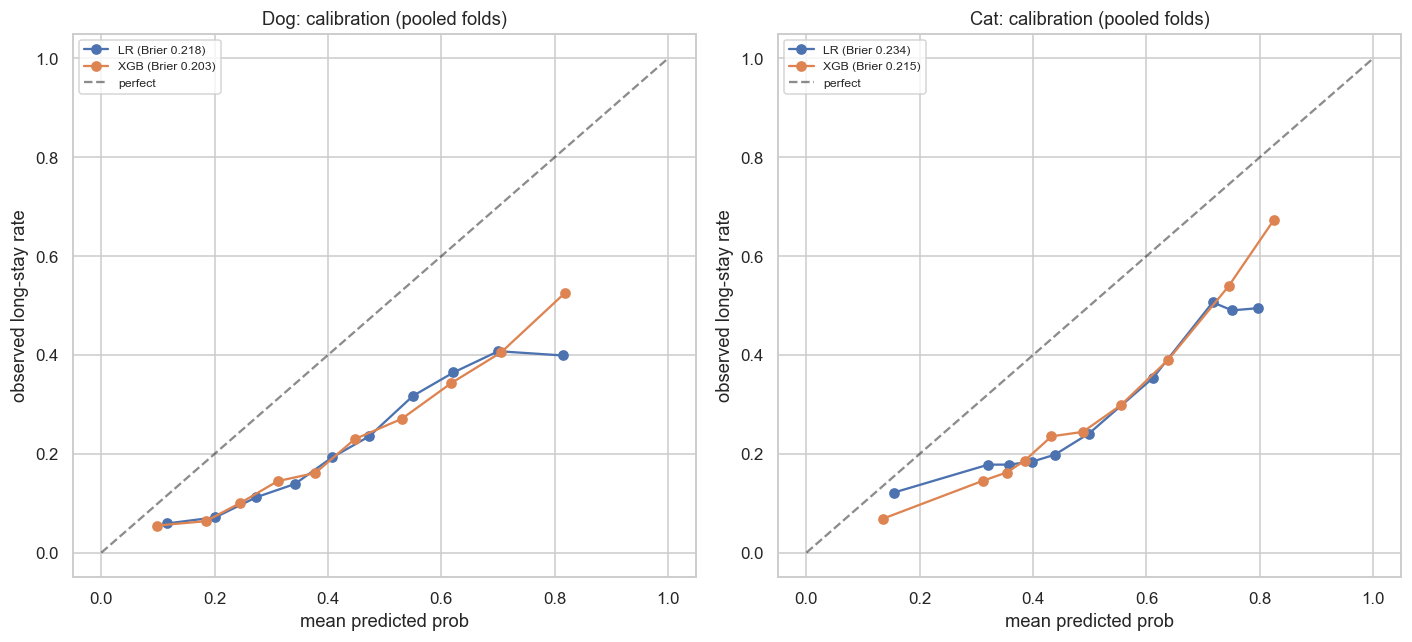

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    for tag in ['LR', 'XGB']:
        ys, ps = pooled(sp, tag)
        frac, mean = calibration_curve(ys, ps, n_bins=10, strategy='quantile')
        ax.plot(mean, frac, marker='o', label=f'{tag} (Brier {brier_score_loss(ys, ps):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    ax.set_title(f'{sp}: calibration (pooled folds)'); ax.set_xlabel('mean predicted prob')
    ax.set_ylabel('observed long-stay rate'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 10. Interpretability — what drives long-stay risk (reference-fold models, train ≤ 2023)

These coefficients / SHAP values come from the **reference fold's** fitted models (the same ones evaluated on test 2024), with the feature set already locked on the 2023 validation fold (§7). They read off the trained model, not the 2024 test labels, so they reflect a single, recent, leakage-safe fit — not an average over folds. **Direction:** positive coefficients / SHAP values push **toward** long stay (higher risk); negative push away (animal leaves sooner).

### 10.1 LR coefficients (log-odds; red = lowers, green = raises long-stay odds — green = higher long-stay risk)

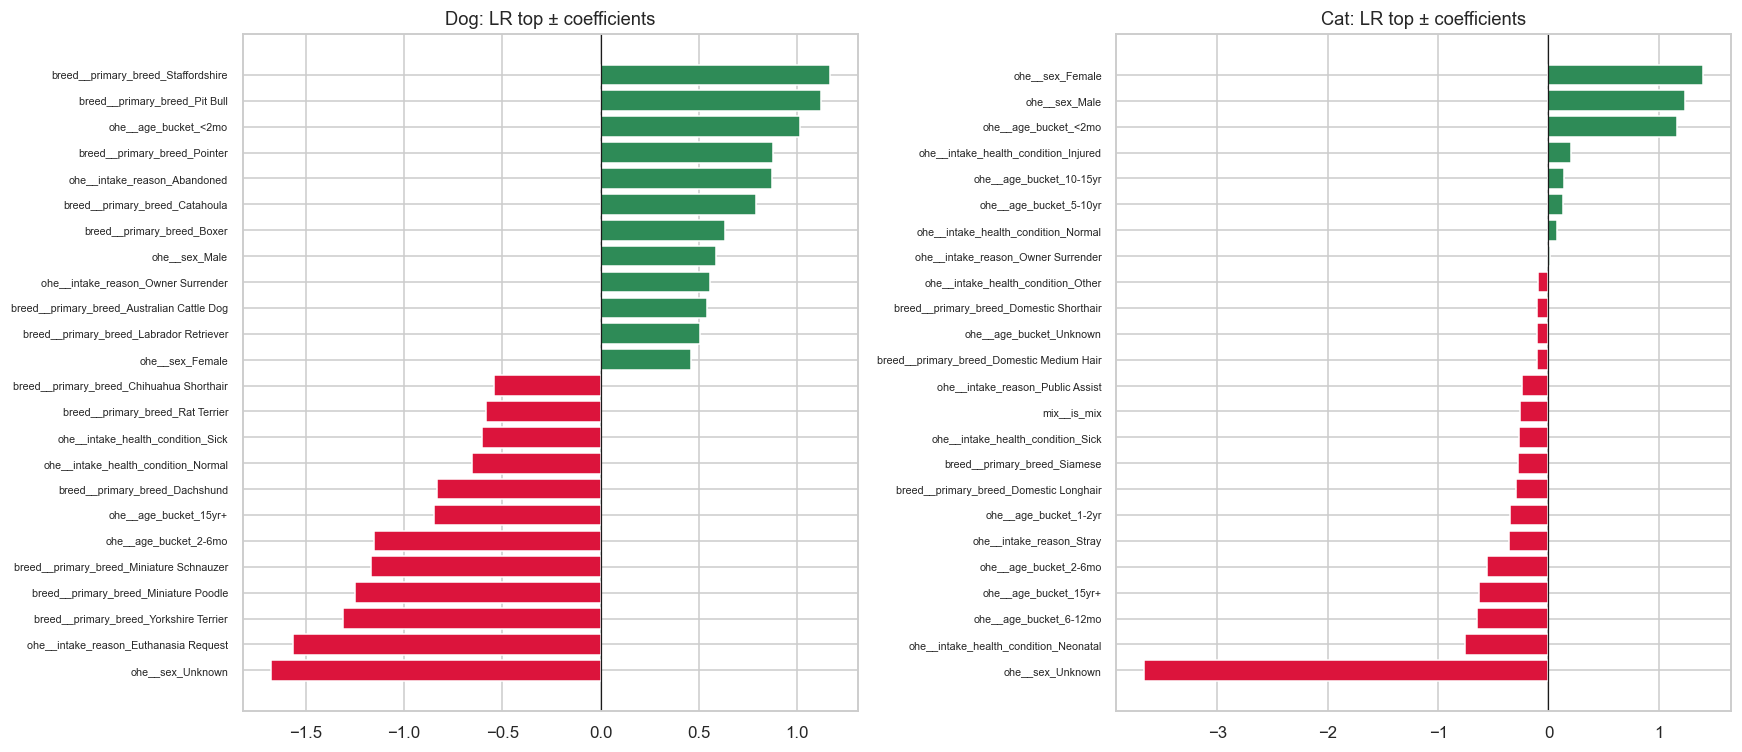

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, sp in zip(axes, ['Dog', 'Cat']):
    pipe = LR_MODELS[sp]
    names = pipe.named_steps['pre'].get_feature_names_out()
    s = pd.Series(pipe.named_steps['clf'].coef_[0], index=names).sort_values()
    top = pd.concat([s.head(12), s.tail(12)])
    ax.barh(range(len(top)), top.values,
            color=['crimson' if v < 0 else 'seagreen' for v in top.values])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7)
    ax.axvline(0, color='k', lw=0.8); ax.set_title(f'{sp}: LR top ± coefficients')
fig.tight_layout(); plt.show()

### 10.2 XGBoost SHAP (computed on TRAIN; not impurity importance, which is biased for high-cardinality) — positive SHAP pushes toward long stay

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_49843/1372375209.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


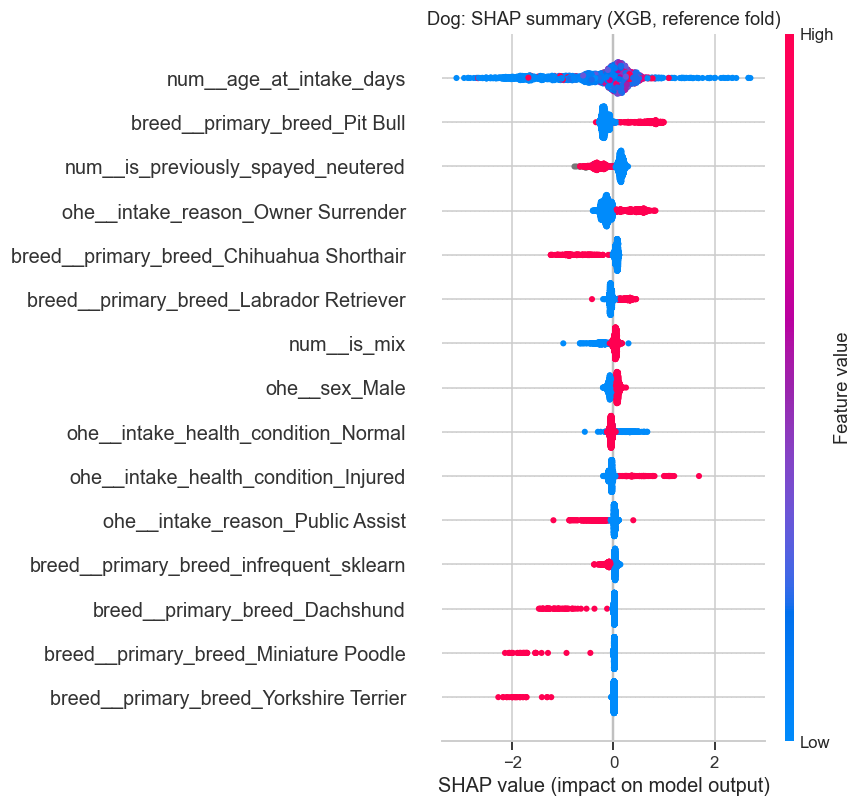

/var/folders/xv/__dg3mss3f1d57y41qhwz0dh0000gn/T/ipykernel_49843/1372375209.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)


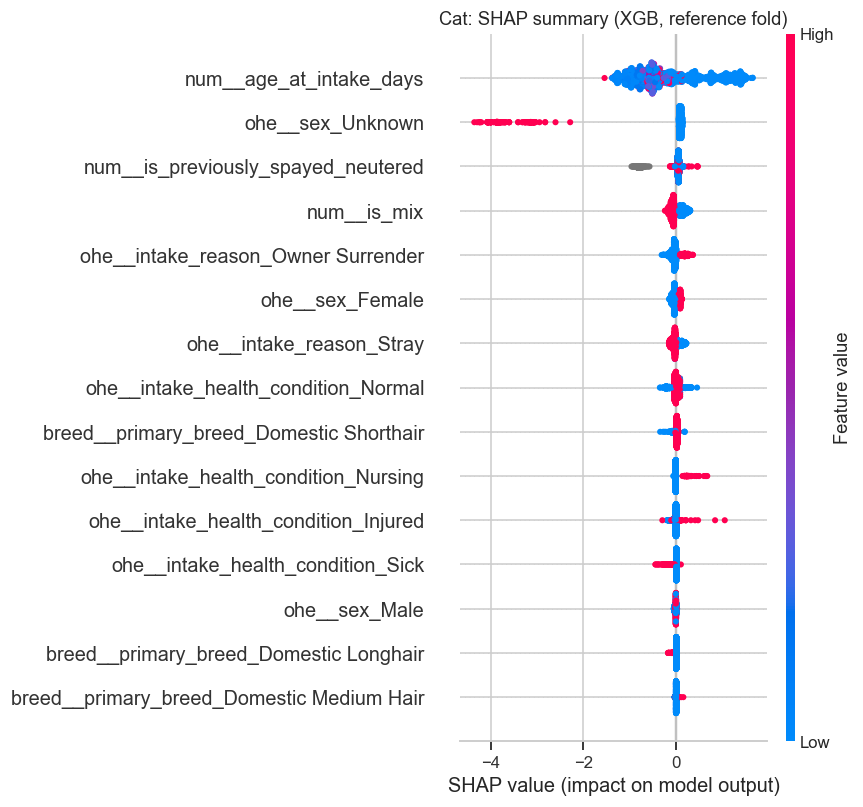

In [17]:
SHAP_INFO = {}
for sp in ['Dog', 'Cat']:
    pre, final = XGB_MODELS[sp]
    names = list(pre.get_feature_names_out())
    samp = REF_TR[sp].sample(min(2500, len(REF_TR[sp])), random_state=RANDOM_STATE)
    Z = pre.transform(samp)
    sv = shap.TreeExplainer(final).shap_values(Z)
    SHAP_INFO[sp] = (names, np.abs(sv).mean(0))
    plt.figure()
    shap.summary_plot(sv, Z, feature_names=names, max_display=15, show=False)
    plt.title(f'{sp}: SHAP summary (XGB, reference fold)'); plt.tight_layout(); plt.show()

## 11. Summary (fill-in-the-blank)

### Performance (rolling-origin backtest, test years 2020–2024)
- Best model per species (by recall/precision at the operating threshold + AUC): dogs → ____ , cats → ____ .
- Operating threshold (recall≥0.80 on pooled 2022–2023) and resulting 2024 recall/precision: dog LR ____ , dog XGB ____ , cat LR ____ , cat XGB ____ .
- Backtest AUC (mean ± std over folds): dog LR ____ , dog XGB ____ , cat LR ____ , cat XGB ____ . Stable across folds (small std)? ____ .
- Any fold that breaks the pattern (e.g. the dog 2022 trough)? ____ .
- LR vs XGBoost gap: ____ (is the extra complexity worth it across folds?).
- Calibration (pooled folds): which model's probabilities are trustworthy under the long-stay rate's year-to-year drift (note the §9.2 weighting distortion)? ____ .

### Feature decisions (this notebook — all made on the 2023 validation fold, test folds untouched)
- Color dropped (both species): confirmed non-useful in selection (MI <0.002, no AUC lift).
- Cat `primary_breed` (§7.1, validation fold): kept/dropped per the re-checked long-stay validation delta (see §7.1) — no prior adoption-era result assumed.
- `is_sn` × age collinearity (§7.2, validation fold): VIF mild; `is_sn` dropped from the **LR**, **kept for XGB** — re-checked on the 2023 long-stay validation fold (see §7.2).

### What drives long-stay risk (per species)
- **Dogs:** top features ____ , ____ , ____ (direction).
- **Cats:** top features ____ , ____ , ____ (direction).
- How does age relate to long-stay risk in each species (cf. §4.1 EDA)? ____ .

### Caveats / next steps
- Feature keep/drop decisions were made on the **2023 validation fold** so the 2024 test fold stayed untouched during selection; the backtest then reports honest performance on those test years.
- Time drift is real (the backtest makes it visible) → prefer the better-calibrated model; consider recalibration / periodic retraining.
- `is_sn` × age collinearity was mild (VIF ~1.2 dog / ~1.5 cat) and handled by dropping the redundant `is_sn` from the LR (§7.2); it never affected the backtest AUC, only coefficient reading.
- Operating threshold is chosen on the pooled 2022–2023 out-of-sample predictions (recall≥0.80, max precision) and applied to 2024; re-tune the recall target to the shelter's capacity for early intervention (§8.1 sensitivity table).
- Operating threshold is calibrated on pooled 2022–2023 predictions. Note 2023 is the historical peak in long-stay rate (dogs 0.315 vs a pre-COVID baseline of ~0.12), so the threshold may still be biased high; recommend periodic recalibration after deployment as the long-stay rate continues to drift.

In [18]:
# ============================================================================
# APPENDIX — Diagnostic: where does the 2023 long-stay rate jump come from?
# Analysis-only. Self-contained: re-loads the CSV and rebuilds age_bucket, does
# NOT read or mutate any modeling variable (df / FEATURES / TARGET / folds) and
# writes nothing back into the pipeline. Safe to run or remove with no side effect.
# ============================================================================
import numpy as np
import pandas as pd

_DATA_PATH = '../data/processed/df_full_merged.csv'    # same source as §2
_diag = pd.read_csv(_DATA_PATH)

_TGT = 'is_long_stay'
if _TGT not in _diag.columns:                          # guard: CSV may predate is_long_stay
    _diag[_TGT] = (_diag['length_of_stay_days'] > 30).astype(int)

# age_bucket — identical definition to §3 (NaN age -> its own 'Unknown' bucket)
_AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
_AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
_diag['age_bucket'] = pd.cut(_diag['age_at_intake_days'], bins=_AGE_BINS, labels=_AGE_LABELS,
                             right=False).astype('object').fillna('Unknown')
# fill the categorical dims so groupby never silently drops NaN rows
for _c in ['intake_reason', 'intake_health_condition']:
    _diag[_c] = _diag[_c].fillna('Unknown')

BASELINE_YEARS = [2020, 2021, 2022]   # COVID-era window (treated as non-normal)
FOCUS_YEAR     = 2023                 # post-reopening candidate "new baseline"
DIMENSIONS     = ['intake_reason', 'intake_health_condition', 'age_bucket']
THIN_N         = 100                  # any window with n < THIN_N -> noise, excluded from auto-read

# anchor: overall long-stay rate per window, per species
print(f'Overall long-stay rate  | baseline {BASELINE_YEARS} vs focus {FOCUS_YEAR}:')
for _sp in ['Dog', 'Cat']:
    _s  = _diag[_diag.animal_type == _sp]
    _br = _s[_s.intake_year.isin(BASELINE_YEARS)][_TGT].mean()
    _fr = _s[_s.intake_year == FOCUS_YEAR][_TGT].mean()
    print(f'  {_sp}: {_br:.3f} -> {_fr:.3f}  (delta {_fr - _br:+.3f})')


def _window_stats(frame, dim):
    """within-window rate (mean target), n, and share — share is computed WITHIN this window only."""
    g = frame.groupby(dim)[_TGT].agg(rate='mean', n='count')
    g['share'] = g['n'] / g['n'].sum()
    return g


def diag_table(species, dim):
    sp = _diag[_diag.animal_type == species]
    b  = _window_stats(sp[sp.intake_year.isin(BASELINE_YEARS)], dim)
    f  = _window_stats(sp[sp.intake_year == FOCUS_YEAR], dim)
    t = pd.DataFrame({
        'baseline_rate':  b['rate'],  'focus_rate':  f['rate'],
        'baseline_n':     b['n'],     'focus_n':     f['n'],
        'baseline_share': b['share'], 'focus_share': f['share'],
    })
    # a group present in only one window -> n/share 0 on the missing side (rate stays NaN -> thin-n)
    for _col, _fill in [('baseline_n', 0), ('focus_n', 0), ('baseline_share', 0.0), ('focus_share', 0.0)]:
        t[_col] = t[_col].fillna(_fill)
    t['baseline_n'] = t['baseline_n'].astype(int); t['focus_n'] = t['focus_n'].astype(int)
    t['rate_delta']  = t['focus_rate']  - t['baseline_rate']
    t['share_delta'] = t['focus_share'] - t['baseline_share']
    t['thin_n']      = (t['baseline_n'] < THIN_N) | (t['focus_n'] < THIN_N)
    t = t[['baseline_rate', 'focus_rate', 'rate_delta', 'baseline_n', 'focus_n',
           'baseline_share', 'focus_share', 'share_delta', 'thin_n']]
    return t.sort_values('focus_n', ascending=False)


def _auto_read(t):
    solid = t[~t['thin_n'] & t['rate_delta'].notna()]   # only cells with n>=100 in BOTH windows
    if solid.empty:
        print(f'  auto-read: no solid cells (all thin-n, n<{THIN_N}) -> inconclusive')
        return
    rd, sd = solid['rate_delta'], solid['share_delta']
    r_top, s_top = solid.loc[rd.idxmax()], solid.loc[sd.idxmax()]
    print(f'  auto-read (solid cells, n>={THIN_N} both windows): '
          f'rate_delta median {rd.median():+.3f}, spread (max-min) {rd.max() - rd.min():.3f}')
    print(f'    largest rate_delta : {rd.idxmax()!r:32}  {r_top.rate_delta:+.3f}  '
          f'(focus_rate {r_top.focus_rate:.3f}, focus_n {int(r_top.focus_n)})')
    print(f'    largest share_delta: {sd.idxmax()!r:32}  {s_top.share_delta:+.3f}  '
          f'(focus_rate {s_top.focus_rate:.3f}, focus_n {int(s_top.focus_n)})')


for _sp in ['Dog', 'Cat']:
    for _dim in DIMENSIONS:
        _t = diag_table(_sp, _dim)
        print('\n' + '=' * 92)
        print(f'{_sp}  |  {_dim}   (baseline {BASELINE_YEARS} vs focus {FOCUS_YEAR}; sorted by focus_n desc)')
        print('=' * 92)
        print(_t.round(3).to_string())
        _auto_read(_t)

Overall long-stay rate  | baseline [2020, 2021, 2022] vs focus 2023:
  Dog: 0.192 -> 0.315  (delta +0.124)
  Cat: 0.291 -> 0.300  (delta +0.009)

Dog  |  intake_reason   (baseline [2020, 2021, 2022] vs focus 2023; sorted by focus_n desc)
                    baseline_rate  focus_rate  rate_delta  baseline_n  focus_n  baseline_share  focus_share  share_delta  thin_n
intake_reason                                                                                                                   
Stray                       0.170       0.307       0.137       11105     3091           0.613        0.611       -0.002   False
Owner Surrender             0.253       0.354       0.102        4999     1219           0.276        0.241       -0.035   False
Public Assist               0.146       0.259       0.113        1504      479           0.083        0.095        0.012   False
Abandoned                   0.198       0.341       0.142         504      273           0.028        0.054        0.


Cat  |  age_bucket   (baseline [2020, 2021, 2022] vs focus 2023; sorted by focus_n desc)
            baseline_rate  focus_rate  rate_delta  baseline_n  focus_n  baseline_share  focus_share  share_delta  thin_n
age_bucket                                                                                                              
<2mo                0.444       0.459       0.015        5025     2264           0.380        0.405        0.025   False
2-6mo               0.178       0.177      -0.001        3166     1214           0.240        0.217       -0.022   False
2-5yr               0.201       0.222       0.020        2116     1037           0.160        0.186        0.026   False
1-2yr               0.209       0.186      -0.023        1018      473           0.077        0.085        0.008   False
6-12mo              0.153       0.129      -0.025         815      303           0.062        0.054       -0.007   False
5-10yr              0.270       0.210      -0.060         688  